In [2]:
import math
# Sigmoid turns z into a chance (0 to 1)
def Sigmoid(z):
    return 1 / (1 + math.exp(-z))

hours = 5
z = -1.5 + 0.6 * hours # Formula
chance = Sigmoid(z)  # Get Chance
prediction = "Pass" if chance > 0.5 else "Fail" # Decide
print(f"Chance of passing:{chance:.2f} (That's {chance*100:.0f}%)")
print(f"Prediction:{prediction}")

Chance of passing:0.82 (That's 82%)
Prediction:Pass


In [3]:
hours_list = [2,4,6]
for hours in hours_list:
    z = -1.5 + 0.6 * hours
    chance = Sigmoid(z)
    prediction = "Pass" if chance > 0.5 else "Fail" 
    print(f"Hours: {hours}, Chance: {chance:.2f}, Prediction: {prediction}")  

Hours: 2, Chance: 0.43, Prediction: Fail
Hours: 4, Chance: 0.71, Prediction: Pass
Hours: 6, Chance: 0.89, Prediction: Pass


In [4]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python3.13t.exe -m pip install --upgrade pip


<frozen importlib._bootstrap>:488: RuntimeWarning: The global interpreter lock (GIL) has been enabled to load module 'sklearn.__check_build._check_build', which has not declared that it can run safely without the GIL. To override this behavior and keep the GIL disabled (at your own risk), run with PYTHON_GIL=0 or -Xgil=0.


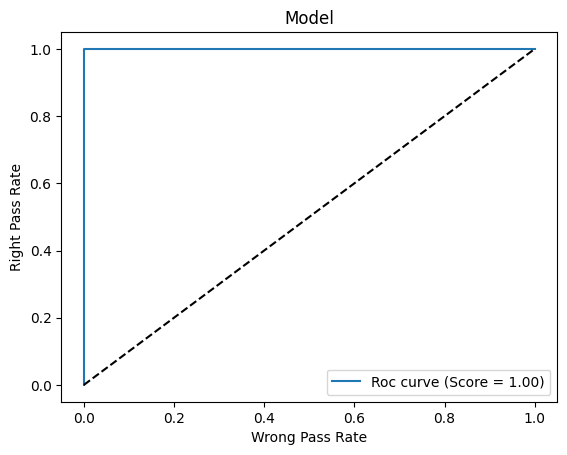

Score = 1.0


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve , auc
import matplotlib.pyplot as plt
import numpy as np

# data
hours = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
real = [0,0,0,1,1,1,1,1,1,1]

model = LogisticRegression()
model.fit(hours,real)
chances = model.predict_proba(hours)[:,1] # chance of pass

# make the curve
false_rate , true_rate , _ = roc_curve(real, chances)
area = auc(false_rate , true_rate)

#draw
plt.plot(false_rate,true_rate , label=f"Roc curve (Score = {area:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("Wrong Pass Rate")
plt.ylabel("Right Pass Rate")
plt.title("Model")
plt.legend()
plt.show()
print("Score =",area)

In [6]:
model = LogisticRegression()
model.fit(hours,real)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [7]:
# make guesses
guesses = model.predict(hours)
chances = model.predict_proba(hours)[:,1]

In [9]:
from sklearn.metrics import confusion_matrix , precision_score , recall_score , f1_score , roc_curve

print("Confusion Table =",confusion_matrix(real,guesses))
print("Precision Score =",precision_score(real,guesses))
print("Recall Score =",recall_score(real,guesses))
print("F1 Score =",f1_score(real,guesses))
print("roc_curve Score =",roc_curve(real,guesses))

Confusion Table = [[3 0]
 [0 7]]
Precision Score = 1.0
Recall Score = 1.0
F1 Score = 1.0
roc_curve Score = (array([0., 0., 1.]), array([0., 1., 1.]), array([inf,  1.,  0.]))


In [10]:
# New Students
new_hours = np.array([[1.5],[5.5]])
new_guess = model.predict(new_hours)
print("Guesses = ",["Fail" if g== 0 else "Pass" for g in new_guess])

Guesses =  ['Fail', 'Pass']
